In [37]:
# Simple MADALINE image recognizer

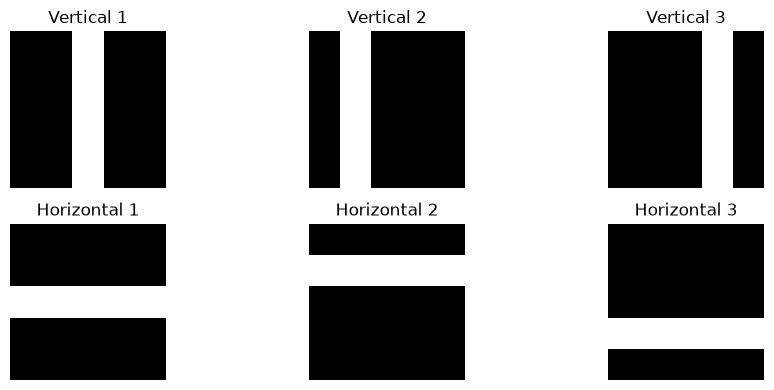

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create simple 5x5 training images
vertical_1 = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0]
])

vertical_2 = np.array([
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

vertical_3 = np.array([
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0]
])

horizontal_1 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

horizontal_2 = np.array([
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

horizontal_3 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0]
])
horizontal_3 = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0]
])


# 2. Display the training images
images = [
    vertical_1,
    vertical_2,
    vertical_3,
    horizontal_1,
    horizontal_2,
    horizontal_3
]

titles = [
    "Vertical 1",
    "Vertical 2",
    "Vertical 3",
    "Horizontal 1",
    "Horizontal 2",
    "Horizontal 3"
]

plt.figure(figsize=(10, 4))

for i, image in enumerate(images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


# 3. Prepare the training data
# Flatten each 5x5 image into 25 input numbers
x = np.array(
    [image.flatten() for image in images],
    dtype=float
)

# Vertical = 1
# Horizontal = -1
y = np.array([
     1,
     1,
     1,
    -1,
    -1,
    -1
])

In [39]:
class Madaline:

    def __init__(
        self,
        n_hidden=3,
        learning_rate=0.1,
        n_iters=1000
    ):
        self.n_hidden = n_hidden
        self.lr = learning_rate
        self.n_iters = n_iters

        self.weights = None
        self.biases = None

    def bipolar_step(self, value):
        # Raw score >= 0 becomes 1
        # Raw score < 0 becomes -1
        return np.where(value >= 0, 1, -1)

    def fit(self, x, y):

        n_samples, n_features = x.shape

        # Each hidden ADALINE neuron gets its own weights
        self.weights = (
            np.random.randn(self.n_hidden, n_features) * 0.01
        )

        # Each hidden neuron gets its own bias
        self.biases = np.zeros(self.n_hidden)

        # Repeat training many times
        for epoch in range(self.n_iters):


            # Look at one image at a time
            for idx, x_i in enumerate(x):

                # Raw score from every hidden neuron
                hidden_raw = (np.dot(self.weights, x_i)+ self.biases)

                # Each hidden neuron votes -1 or 1
                hidden_votes = self.bipolar_step(hidden_raw)

                # Final answer uses majority vote
                prediction = (
                    1 if np.sum(hidden_votes) >= 0 else -1
                )

                # Rule I updates only when prediction is wrong
                if prediction != y[idx]:


                    if y[idx] == 1:
                        # We need more positive votes.
                        # Choose the negative neuron closest to zero.
                        negative_neurons = np.where(
                            hidden_votes == -1
                        )[0]

                        neuron = negative_neurons[
                            np.argmin(
                                np.abs(
                                    hidden_raw[negative_neurons]
                                )
                            )
                        ]

                        # Move that neuron toward +1
                        error = 1 - hidden_raw[neuron]

                        self.weights[neuron] += (
                            self.lr * error * x_i
                        )

                        self.biases[neuron] += (
                            self.lr * error
                        )

                    else:
                        # We need more negative votes.
                        # Update every neuron voting positive.
                        positive_neurons = np.where(
                            hidden_votes == 1
                        )[0]

                        for neuron in positive_neurons:

                            # Move that neuron toward -1
                            error = -1 - hidden_raw[neuron]

                            self.weights[neuron] += (
                                self.lr * error * x_i
                            )

                            self.biases[neuron] += (
                                self.lr * error
                            )


        return self

    def predict(self, x):

        predictions = []

        for x_i in x:

            # Get raw scores from hidden neurons
            hidden_raw = (
                np.dot(self.weights, x_i)
                + self.biases
            )

            # Turn raw scores into votes
            hidden_votes = self.bipolar_step(hidden_raw)

            # Majority vote decides the class
            prediction = (
                1 if np.sum(hidden_votes) >= 0 else -1
            )

            predictions.append(prediction)

        return np.array(predictions)

Image: 1 | Predicted: Vertical | Correct: Vertical
Image: 2 | Predicted: Vertical | Correct: Vertical
Image: 3 | Predicted: Vertical | Correct: Vertical
Image: 4 | Predicted: Horizontal | Correct: Horizontal
Image: 5 | Predicted: Horizontal | Correct: Horizontal
Image: 6 | Predicted: Horizontal | Correct: Horizontal

Accuracy: 100.0 %


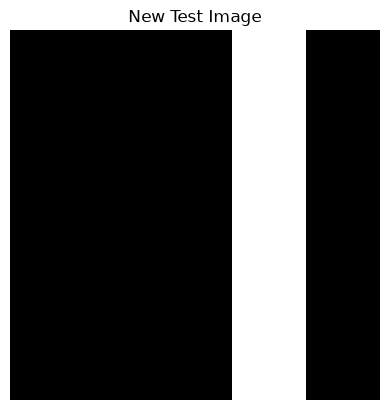

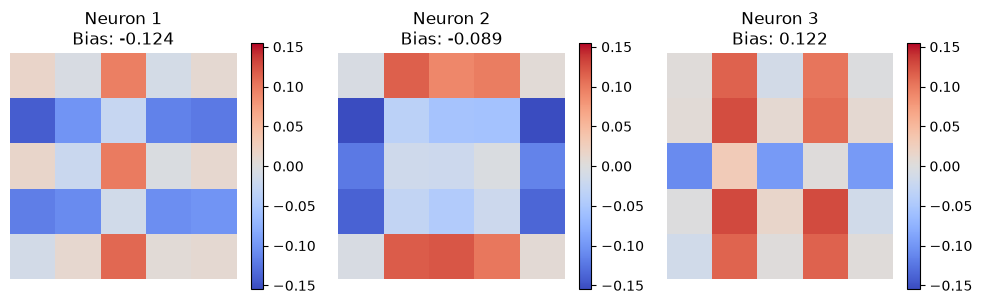

MADALINE predicts: Vertical line


In [40]:
# 5. Train the model
np.random.seed(1)

model = Madaline(
    n_hidden=3,
    learning_rate=0.1,
    n_iters=1000
)

model.fit(x, y)


# 6. Test the training images
predictions = model.predict(x)

for i in range(len(images)):

    if predictions[i] == 1:
        predicted_name = "Vertical"
    else:
        predicted_name = "Horizontal"

    if y[i] == 1:
        correct_name = "Vertical"
    else:
        correct_name = "Horizontal"

    print(
        "Image:",
        i + 1,
        "| Predicted:",
        predicted_name,
        "| Correct:",
        correct_name
    )

accuracy = np.mean(predictions == y)

print("\nAccuracy:", accuracy * 100, "%")


# 7. Create a new image
new_image = np.array([
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 1, 0]
])

plt.imshow(new_image, cmap="gray")
plt.title("New Test Image")
plt.axis("off")
plt.show()


# 8. Visualize what each neuron learned
plt.figure(figsize=(10, 3))

largest_weight = np.max(np.abs(model.weights))

for neuron in range(model.n_hidden):

    learned_pattern = model.weights[neuron].reshape(5, 5)

    plt.subplot(1, model.n_hidden, neuron + 1)

    plt.imshow(
        learned_pattern,
        cmap="coolwarm",
        vmin=-largest_weight,
        vmax=largest_weight
    )

    plt.title(
        f"Neuron {neuron + 1}\n"
        f"Bias: {model.biases[neuron]:.3f}"
    )

    plt.colorbar()
    plt.axis("off")

plt.tight_layout()
plt.show()


# 9. Predict the new image
new_x = new_image.flatten().reshape(1, -1).astype(float)

new_prediction = model.predict(new_x)[0]

if new_prediction == 1:
    print("MADALINE predicts: Vertical line")
else:
    print("MADALINE predicts: Horizontal line")